# Customer Segmentation Analysis pada Supermarket
# Pendekatan RFM, Demografi, dan Efektivitas Kampanye untuk Mendukung Strategi Pemasaran

# Latar Belakang

Dalam ekosistem ritel supermarket yang sangat kompetitif, untuk mencapai kesuksesan tidak hanya dituntut untuk meningkatkan penjualan, tetapi juga mampu mempertahankan pelanggan serta menjalankan strategi pemasaran yang tepat sasaran. Setiap pelanggan adalah individu yang unik dengan latar belakang demografis yang bervariasi, pola perilaku belanja yang berbeda, serta tingkat respons yang beragam terhadap kampanye promosi, maka pendekatan universal yang menyamaratakan semua pelanggan tidak lagi efektif.

Project ini bertujuan untuk menganalisis perilaku pelanggan menggunakan pendekatan **Recency, Frequency, dan Monetary (RFM)** sebagai dasar segmentasi pelanggan, dan mengombinasikannya dengan **demografis & analisis respons kampanye pemasaran**. Melalui segmentasi ini, perusahaan diharapkan dapat mengidentifikasi pelanggan bernilai tinggi, pelanggan yang berisiko hilang, serta efektivitas promosi kampanye terhadap masing-masing segmen.

## Pernyataan Masalah
Berdasarkan latar belakang tersebut, pernyataan masalah dalam proyek ini adalah:

Bagaimana perusahaan supermarket dapat mengembangkan segmentasi pelanggan yang efektif dengan memanfaatkan analisis RFM, data demografi, dan respons terhadap campaign pemasaran dalam meningkatkan ketepatan strategi pemasaran, retensi pelanggan, dan nilai bisnis?

# Data

Untuk menjawab pertanyaan di atas, saya akan menganalisa data pelanggan yang sudah dikumpulkan oleh perusahaan.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency, ttest_ind, f_oneway

import re
import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi informasi terkait data pribadi, produk, promosi, tempat pembelian.Terdapat 28 kolom di dalam dataset **Supermarket Customers**, yaitu:

**Data Pribadi (People)**
* ID: Identitas unik pelanggan
* Year_Birth: Tahun kelahiran pelanggan
* Education: Tingkat pendidikan pelanggan
* Marital_Status: Status pernikahan pelanggan
*Income: Pendapatan rumah tangga pelanggan per tahun
* Kidhome: Jumlah anak kecil dalam rumah tangga pelanggan
* Teenhome: Jumlah anak remaja dalam rumah tangga pelanggan
* Dt_Customer: Tanggal pelanggan mulai terdaftar sebagai pelanggan perusahaan
* Recency: Jumlah hari sejak pembelian terakhir pelanggan
* Complain: 1 jika pelanggan pernah mengajukan keluhan dalam 2 tahun terakhir, 0 jika tidak


**Produk (Products)**
* MntWines: Total pengeluaran untuk produk anggur (wine) dalam 2 tahun terakhir
* MntFruits: Total pengeluaran untuk buah-buahan dalam 2 tahun terakhir
* MntMeatProducts: Total pengeluaran untuk produk daging dalam 2 tahun terakhir
* MntFishProducts: Total pengeluaran untuk produk ikan dalam 2 tahun terakhir
* MntSweetProducts: Total pengeluaran untuk produk manisan dalam 2 tahun terakhir
* MntGoldProds: Total pengeluaran untuk produk emas dalam 2 tahun terakhir

**Promosi (Promotion)**
* NumDealsPurchases: Jumlah pembelian dengan diskon
* AcceptedCmp1: 1 jika pelanggan menerima penawaran pada kampanye pertama, 0 jika tidak
* AcceptedCmp2: 1 jika pelanggan menerima penawaran pada kampanye kedua, 0 jika tidak
* AcceptedCmp3: 1 jika pelanggan menerima penawaran pada kampanye ketiga, 0 jika tidak
* AcceptedCmp4: 1 jika pelanggan menerima penawaran pada kampanye keempat, 0 jika tidak
* AcceptedCmp5: 1 jika pelanggan menerima penawaran pada kampanye kelima, 0 jika tidak
* Response: 1 jika pelanggan menerima penawaran pada kampanye terakhir, 0 jika tidak

**Tempat Pembelian (Place)**
* NumWebPurchases: Jumlah pembelian melalui website
* NumCatalogPurchases: Jumlah pembelian melalui katalog
* NumStorePurchases: Jumlah pembelian langsung di toko
* NumWebVisitsMonth: Jumlah kunjungan ke website dalam 1 bulan terakhi

Berikut 5 baris teratas dan terbawah dari dataset **Supermarket Customers**.

In [5]:
df = pd.read_csv('Supermarket Customers.csv', sep='\t')
display(df.head(),df.tail())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


## Data Understanding
Sebelum masuk ke dalam analisis, kita perlu mengenal dataset kita lebih jauh dalam tahapan *data understanding*. Dari proses ini, kita akan tahu anomali-anomali apa saja yang terdapat di dalam dataset kita dan perlu ditangani dalam tahapan *Data Cleaning*. Setiap penanganan anomali yang dilakukan, akan disertai dengan justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
display(df.describe(), df.describe(include='object'))

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


Menampilkan ringkasan statistik deskriptif dari data numerikal dan ringkasan statistik kategorikal  

In [8]:
pd.set_option('display.max_colwidth', None)
# data unique di tiap kolom
list_item = []
for col in df.columns :
    list_item.append( [col, df[col].nunique(), df[col].unique()])

tabel_desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'], data=list_item)
tabel_desc

,Column Name,Number of Unique,Unique Sample
0,ID,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 4855, 5899, 1994, 387, 2125, 8180, 2569, 2114, 9736, 4939, 6565, 2278, 9360, 5376, 1993, 4047, 1409, 7892, 2404, 5255, 9422, 1966, 6864, 3033, 5710, 7373, 8755, 10738, 4339, 10755, 8595, 2968, 8601, 503, 8430, 7281, 2139, 1371, 9909, 7286, 7244, 6566, 8614, 4114, 1331, 2225, 9381, 6260, 10383, 7437, 8557, 8375, 6853, 3076, 1012, 6518, 4137, 8082, 1386, 9369, 4477, 1357, 1402, 10629, 6312, 8132, 1050, 5846, 1859, 7503, 10401, 1618, 3332, 2261, 5346, 4119, 535, 5268, 273, 4452, 8504, 771, 8996, 9235, 5798, 11178, 2230, 7516, 7247, 11100, 4646, 3037, ...]"
1,Year_Birth,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 1974, 1950, 1983, 1976, 1959, 1952, 1987, 1946, 1980, 1949, 1982, 1979, 1951, 1969, 1986, 1989, 1963, 1970, 1973, 1943, 1975, 1996, 1968, 1964, 1977, 1978, 1955, 1966, 1988, 1948, 1958, 1972, 1960, 1945, 1991, 1962, 1953, 1961, 1956, 1992, 1900, 1893, 1990, 1947, 1899, 1993, 1994, 1941, 1944, 1995, 1940]"
2,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, Alone, Absurd, YOLO]"
4,Income,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, 62513.0, 55635.0, 33454.0, 30351.0, 5648.0, nan, 7500.0, 63033.0, 59354.0, 17323.0, 82800.0, 41850.0, 37760.0, 76995.0, 33812.0, 37040.0, 2447.0, 58607.0, 65324.0, 40689.0, 18589.0, 53359.0, 38360.0, 84618.0, 10979.0, 38620.0, 40548.0, 46610.0, 68657.0, 49389.0, 67353.0, 23718.0, 42429.0, 48948.0, 80011.0, 20559.0, 21994.0, 79941.0, 41728.0, 72550.0, 65486.0, 79143.0, 35790.0, 82582.0, 66373.0, 82384.0, 70287.0, 27938.0, 55954.0, 75777.0, 66653.0, 61823.0, 67680.0, 70666.0, 25721.0, 32474.0, 88194.0, 69096.0, 74854.0, 66991.0, 65031.0, 60631.0, 28332.0, 40246.0, 75251.0, 75825.0, 26326.0, 56046.0, 29760.0, 26304.0, 23559.0, 81361.0, 29440.0, 36138.0, 50388.0, 79593.0, 54178.0, 42394.0, 23626.0, 30096.0, 47916.0, 51813.0, 78497.0, 50150.0, 47823.0, 34554.0, 85693.0, 65846.0, 87195.0, 24594.0, 49096.0, 52413.0, 38557.0, 89058.0, 77298.0, ...]"
5,Kidhome,3,"[0, 1, 2]"
6,Teenhome,3,"[0, 1, 2]"
7,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-2014, 19-01-2014, 09-09-2013, 13-11-2012, 08-05-2013, 06-06-2013, 13-03-2014, 15-11-2013, 10-10-2012, 24-11-2012, 24-12-2012, 31-08-2012, 28-03-2013, 03-11-2012, 08-08-2012, 06-01-2013, 23-12-2012, 11-01-2014, 18-03-2013, 02-01-2013, 27-05-2013, 20-02-2013, 31-05-2013, 22-11-2013, 22-05-2014, 11-05-2013, 29-10-2012, 29-08-2013, 31-12-2013, 02-09-2013, 11-02-2014, 01-02-2013, 29-04-2013, 12-03-2013, 05-11-2013, 02-10-2013, 28-06-2014, 09-11-2012, 24-05-2013, 01-01-2014, 08-11-2012, 12-05-2014, 11-08-2012, 07-06-2014, 12-06-2013, 19-11-2012, 02-04-2013, 28-04-2014, 17-06-2013, 03-03-2014, 04-07-2013, 07-09-2012, 18-02-2013, 11-06-2013, 06-12-2013, 21-05-2013, 11-05-2014, 19-03-2014, 27-09-2013, 08-04-2013, 11-09-2012, 14-09-2012, 17-03-2013, 05-04-2013, 30-04-2014, 19-12-2012, 27-08-2012, 12-10-2012, 04-09-2013, 29-08-2012, 23-06-2013, 03-07-2013, 25-02-2014, 11-08-2013, 16-07-2013, 28-05-2014, 21-01-2014, 27-05-2014, 23-11-2013, 23-03-2014, 24-05-2014, 22-11-2012, 11-04-2013, 01-12-2013, 20-06-2013, 23-07-2013, 30-03-2014, 20-04-2013, 17-05-2013, 08-05-2014, 10-12-2013, 24-09-2013, 02-02-2013, 07-12-2012, 02-11-2013, 10-11-2012, 25-06-2014, ...]"
8,Recency,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82, 53, 23, 51, 20, 91, 86, 41, 42, 63, 0, 69, 89, 4, 96, 56, 31, 8, 55, 37, 76, 99, 3, 88, 80, 72, 24, 92, 39, 29, 2, 54, 57, 30, 12, 18, 75, 90, 1, 25, 40, 9, 87, 5, 95, 48, 70, 79, 45, 84, 44, 43, 35, 15, 17, 46, 27, 74, 85, 65, 13, 83, 10, 21, 61, 73, 47, 36, 49, 28, 64, 98, 78, 77, 81, 14, 52, 93, 50, 60, 66, 97, 62, 6, 33, 67, 22, 71, 7]"
9,MntWines,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6, 194, 233, 3, 1006, 53, 84, 1012, 4, 86, 1, 867, 384, 270, 36, 684, 8, 112, 110, 96, 482, 40, 702, 55, 437, 421, 13, 9, 81, 123, 48, 826, 245, 650, 12, 510, 3

Secara umum, kita bisa melihat bahwa:

* Dataset Supermarket Customers  memiliki 28 kolom dan 2240 baris
* Nama-nama kolom pada dataset tersebut tidak konsisten dalam penamaan sebuah kolom, sehingga menyulitkan dalam proses pengerjaan.
* Hanya satu kolom yaitu, 'Income' memiliki data kosong. Data kosong pada kolom-kolom tersebut diwakili dengan data NaN.
* Kolom 'Z_CostContact' & 'Z_Revenue' hanya berisikan satu nilai unik, sehingga tidak relevan dalam analisis.
* Kolom 'Dt_Customer'  memiliki data bertipe object. Namun untuk keperluan analisis, kolom ini seharusnya berisikan data Datetime.
* Kolom 'Year_Birth' terdapat data yang jika diakumulakisakan ke dalam tahun berjalan maka nilainya lebih dari 100 tahun.
* Kolom 'Education' memiliki data yang kurang sesuai jika diasumsikan ke dalam sebuah kategori/pengelompokan data.
* Kolom 'Marital_Status' memiliki data yang kurang sesuai jika diasumsikan ke dalam sebuah kategori/pengelompokan data.
* Perlu penambahan beberapa kolom baru  untuk memudahkan tahap analisis.

## Data Cleaning dan Data Formatting

In [9]:
df_cleaning = df.copy()

In [10]:
# Merubah format nama kolom
df_cleaning.rename(columns={'ID': 'id'}, inplace=True)
df_cleaning.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in df_cleaning.columns]
df_cleaning.columns = df_cleaning.columns.str.replace('__', '_')

In [11]:
display(df_cleaning.columns)

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mnt_wines', 'mnt_fruits',
       'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products',
       'mnt_gold_prods', 'num_deals_purchases', 'num_web_purchases',
       'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month',
       'accepted_cmp3', 'accepted_cmp4', 'accepted_cmp5', 'accepted_cmp1',
       'accepted_cmp2', 'complain', 'z_cost_contact', 'z_revenue', 'response'],
      dtype='object')

Pada seluruh nama kolom diseragamkan menggunakan format *snake_case* dengan agar mempermudah dalam proses pengerjaan analisis  data dan jika sewaktu-waktu ingin melakukan analisis pada SQL juga bisa langsung terbaca dengan jelas dan aman.

In [12]:
# Merubah Data type menjadi Datetime
df_cleaning['dt_customer'] = pd.to_datetime(df_cleaning['dt_customer'], format='%d-%m-%Y')

Data type pada `dt_customer` dirubah yang sebelumnya 'object' menjadi 'datetime' karena memerlukan time series untuk keperluan analisis waktu berkaitan dengan `tenure` dan `age`

In [13]:
# Text formatting & konsistensi pada data bertipe object
df_cleaning['education'] = df_cleaning['education'].str.strip()

In [14]:
# Text formatting untuk kategorikal kolom
df_cleaning['marital_status'] = df_cleaning['marital_status'].str.strip().str.title()

In [15]:
df_cleaning['education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [16]:
df_cleaning['marital_status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'Yolo'], dtype=object)

Pada kolom `education` dan `marital_status` dilakukan penyesuaian kembali juga agar fromat value di dalamnya terjaga dan konsisten  

### Missing Value

In [17]:
# Identifikasi missing value
missing_data = pd.DataFrame({'Missing Count': df_cleaning.isna().sum(),'Missing Percentage': df_cleaning.isna().sum() / df.shape[0] * 100})
display(missing_data[missing_data['Missing Count'] > 0])

,Missing Count,Missing Percentage
income,24,1.071429


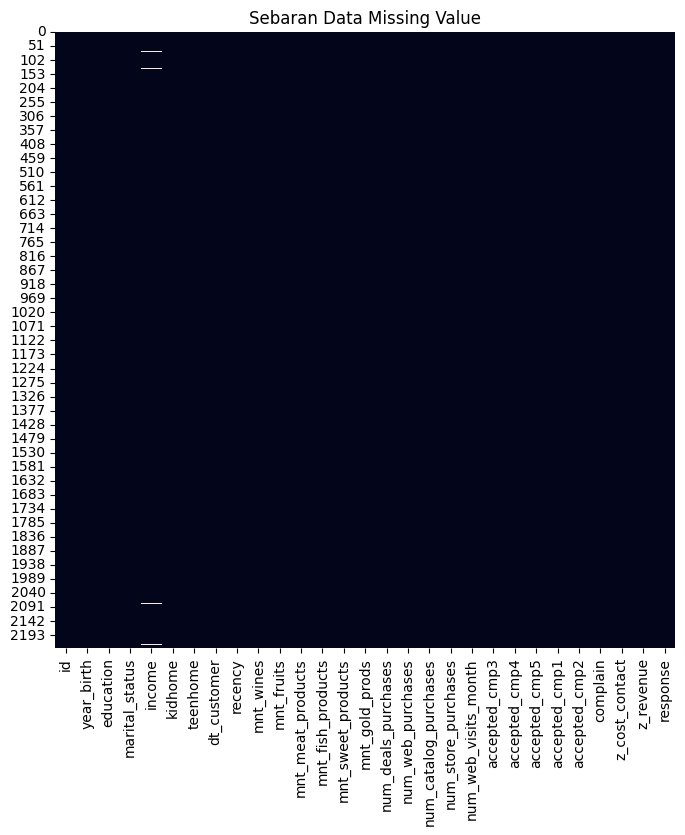

In [18]:
# Sebaran missing value di dalam data
plt.figure(figsize=(8,8))
sns.heatmap (df_cleaning.isna(), cbar=False)
plt.title('Sebaran Data Missing Value')
plt.show()

Identifikasi missing value:

* Missing value di kolom 'income'memiliki proporsi yang rendah sekitar 1,07% bisa disimpulkan bahwa tidak akan signifikan dalam memengaruhi analisis secara kesuluruhan, penyebabnya mungkin adalah terkait sensitivitas data bagi sebagian orang.

Cara untuk menangani missing value:

* Pertama, menghapus baris/kolom yang berisi missing value. Cara ini tidak disarankan, karena meskipun jumlah missing value yang tergolong cukup kecil (sekitar 1,07%) namun data customer ini masih cukup berguna pada unsur lain seperti keaktifan dalam berbelanja, respon terhadap campaign, status ke-loyal-an customer.
* Kedua, mengisi data yang hilang. Cara ini lebih disarankan. Ada beberapa metode yang bisa digunakan untuk mengisi missing value, cara yang paling baik pada case ini adalah dengan mengisi data yang hilang dengan median, karena median tidak sensitif terhadap outlier dibandingkan mean, dan data income cenderung memiliki distribusi yang miring.

In [19]:
# Handling missing value dengan imputation data
df_cleaning['income'] = df_cleaning['income'].fillna(df_cleaning['income'].median())

Pada pengisian data pada kolom 'income' dipilih menggunakan median karena tidak sensitif terhadap outlier dibandingkan mean, dan data income cenderung memiliki distribusi yang miring.

In [20]:
# Pengecekan kembali missing value
df_cleaning.isna().sum()

id                       0
year_birth               0
education                0
marital_status           0
income                   0
kidhome                  0
teenhome                 0
dt_customer              0
recency                  0
mnt_wines                0
mnt_fruits               0
mnt_meat_products        0
mnt_fish_products        0
mnt_sweet_products       0
mnt_gold_prods           0
num_deals_purchases      0
num_web_purchases        0
num_catalog_purchases    0
num_store_purchases      0
num_web_visits_month     0
accepted_cmp3            0
accepted_cmp4            0
accepted_cmp5            0
accepted_cmp1            0
accepted_cmp2            0
complain                 0
z_cost_contact           0
z_revenue                0
response                 0
dtype: int64

### Data Outlier

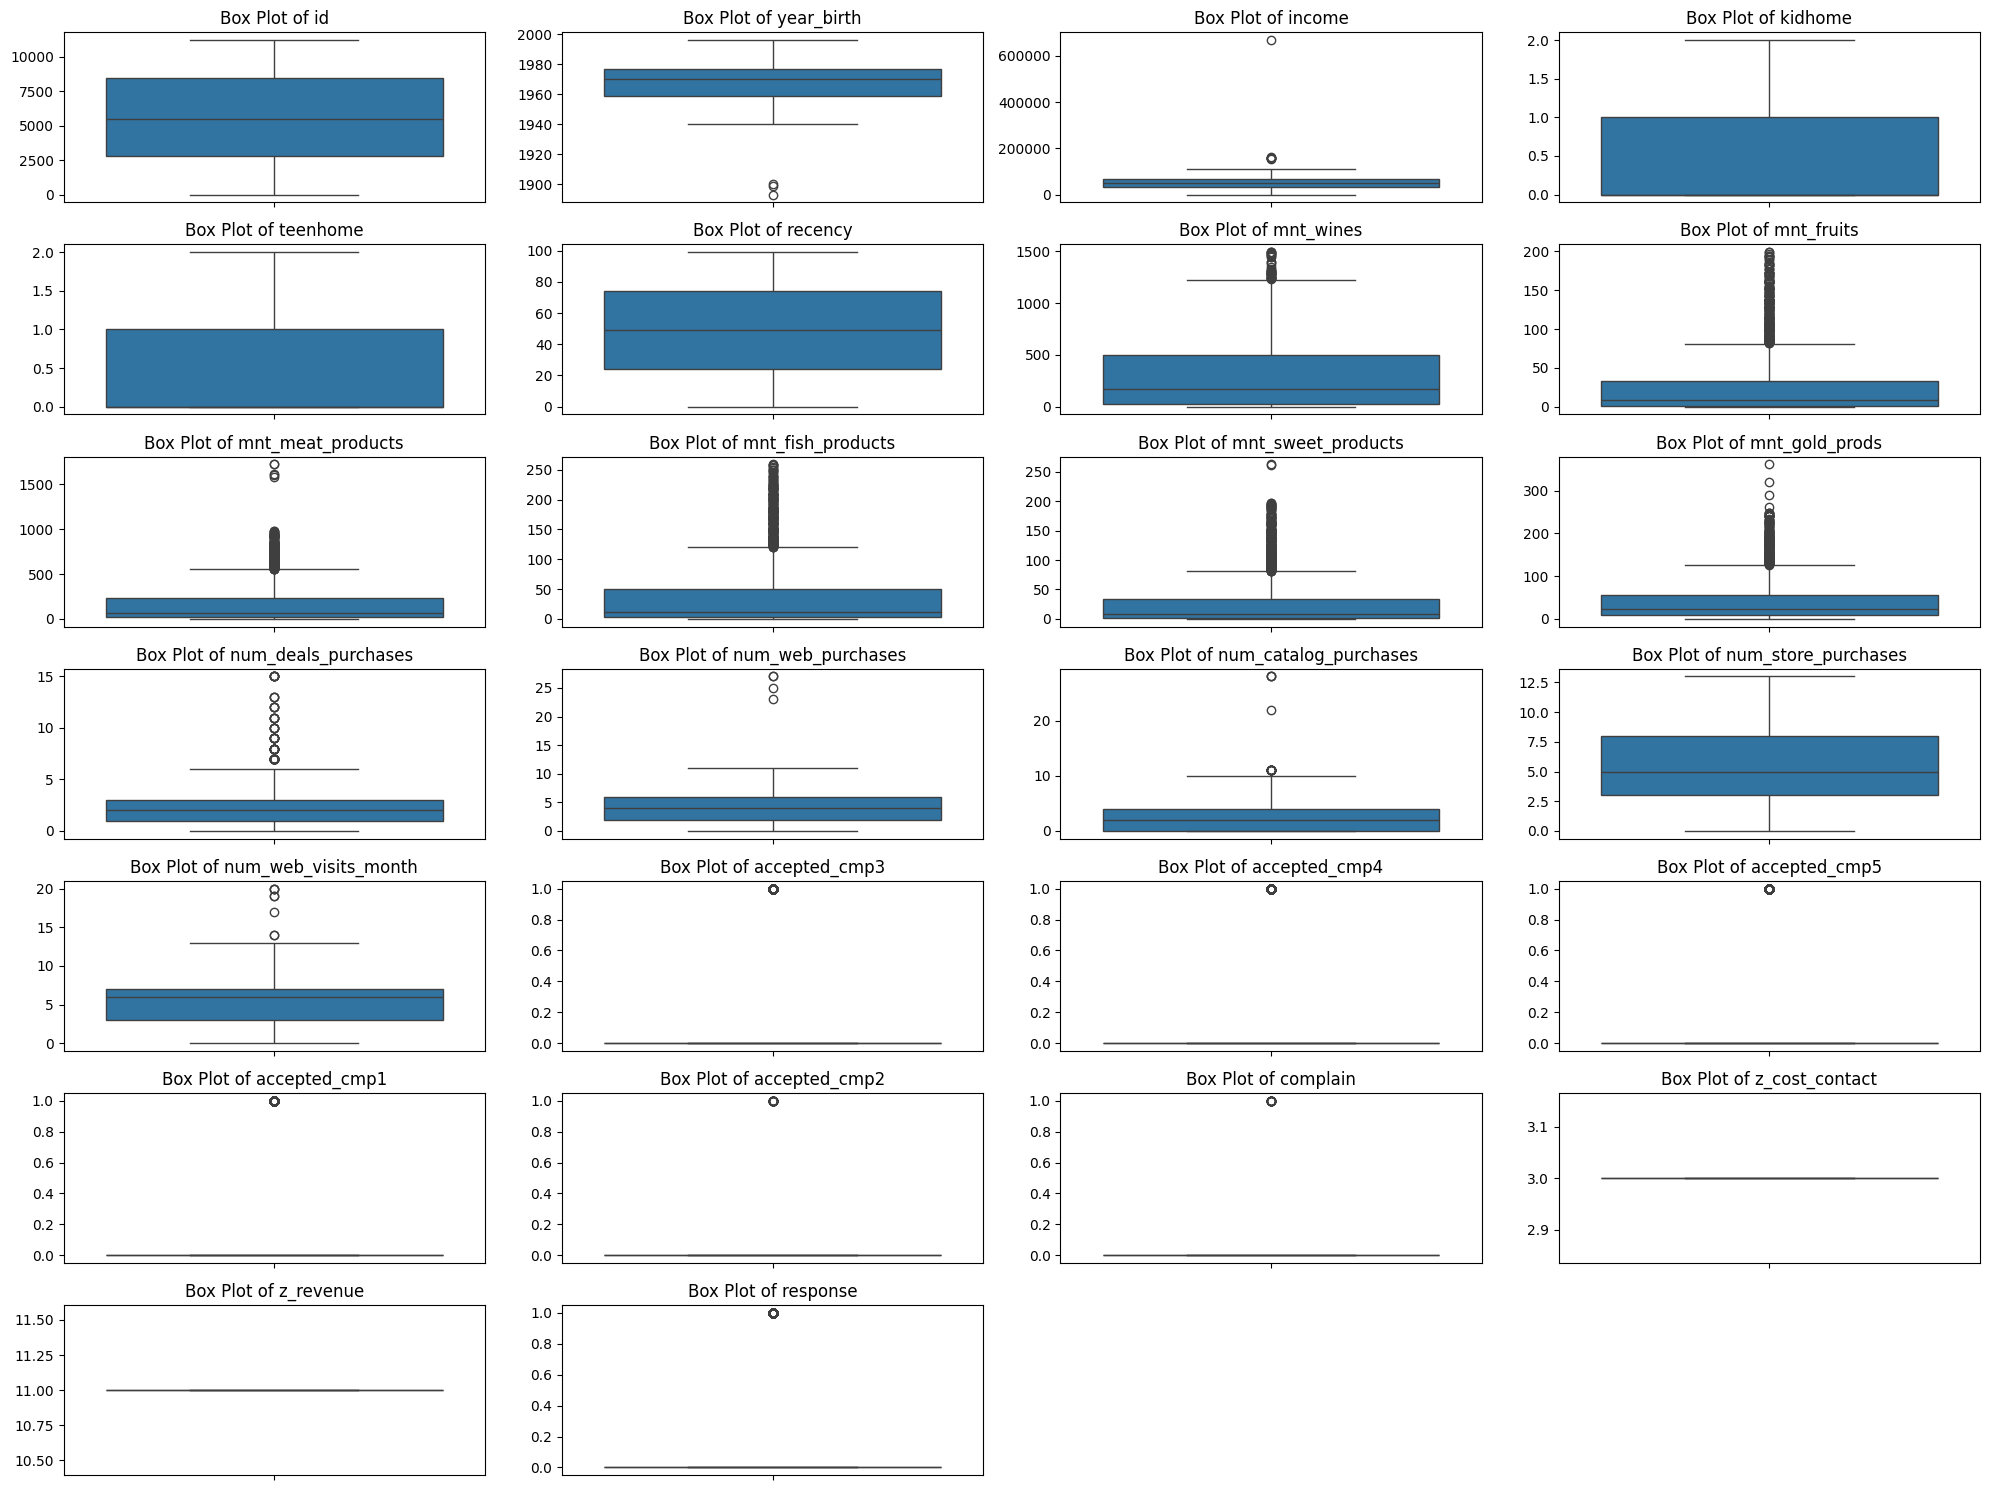

In [21]:
# Pengecekan data outlier dengan boxplot
numerical_cols = df_cleaning.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(round(len(numerical_cols)/4)  +1, 4, i + 1)
    sns.boxplot(y=df_cleaning[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Kode di atas akan menghasilkan serangkaian box plot untuk setiap kolom numerik dalam DataFrame `df_cleaning`. Dari box plot ini, dapat kita lihat terdapat beberapa kolom-kolom yang menunjukan outlier, antara lain:
* `year_birth`: Terdapat beberapa pelanggan yang sangat tua (jika tahun lahirnya diinterpretasikan secara langsung) dan perlu dilakukan sebuah tindakan.
* `income`: Ada beberapa pelanggan dengan pendapatan yang sangat tinggi, jauh di atas rata-rata.
* `mnt_wines`, `mnt_meat_products`, `mnt_fruits`, `mnt_fish_products`, `mnt_sweet_products`, `mnt_gold_prods` (kolom pengeluaran/montant): Kolom-kolom ini menunjukkan beberapa titik data di bagian atas (nilai positif yang sangat besar), yang berarti terdapat pelanggan yang mengeluarkan uang cukup banyak untuk kategori produk tertentu.
* `num_web_visits_month` : Kolom ini juga menunjukkan beberapa pelanggan dengan jumlah kunjungan web yang sangat tinggi.

In [22]:
# Identifikasi tahun terakhir
current_year = df_cleaning['dt_customer'].dt.year.max()
current_year

np.int32(2014)

In [23]:
# Menambahkan feature Age
df_cleaning['age'] = current_year - df_cleaning['year_birth']

In [24]:
q1 = df_cleaning['age'].quantile(0.25)
q3 = df_cleaning['age'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df_cleaning[(df_cleaning['age'] < lower) | (df_cleaning['age'] > upper)]
outliers

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,...,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,0,1,3,11,0,114
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,0,3,11,0,121
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,0,1,0,0,0,3,11,0,115


In [25]:
df_cleaning = df_cleaning[df_cleaning['age'] <= 80]

In [26]:
# Mereset indeks df_cleaning
df_cleaning.reset_index(drop=True, inplace=True)

Setelah mereset indeks, cek `df_cleaning` dan informasi indeksnya untuk memastikan perubahan telah diterapkan.

In [27]:
display(df_cleaning.head(), df_cleaning.tail())

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,...,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,57
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,60
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,49
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,33


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,...,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age
2232,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,3,11,0,47
2233,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,1,0,0,3,11,0,68
2234,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,1,0,0,0,0,3,11,0,33
2235,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,3,11,0,58
2236,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,...,0,0,0,0,0,0,3,11,1,60


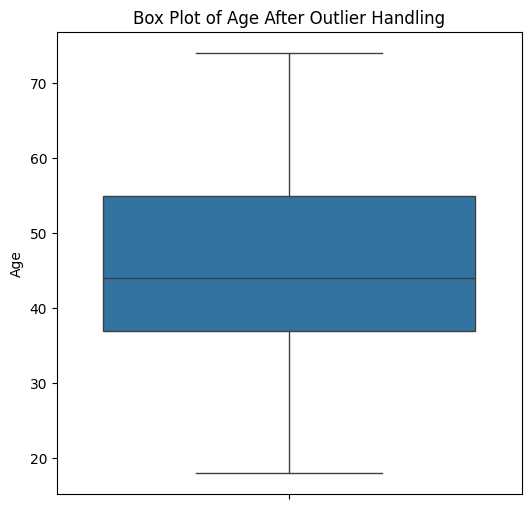

In [28]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=df_cleaning['age'])
plt.title('Box Plot of Age After Outlier Handling')
plt.ylabel('Age')
plt.show()

Telah dilakukan sebuah penanganan terhadap kolom `year_birth` dengan menambahkan kolom `age` untuk memudahkan dalam penanganan outlier yang mana data customer dengan umur di atas 80 akan dihapus karena beberapa pertimbangan, yaitu:
* Tidak relevan dengan demografi pelanggan target saat ini.
* Jumlahnya relatif kecil hanya sebanyak 3 baris.
* Tidak melakukan imputasi dengan mean/median karena dapat merefleksikan profil pelanggan yang sebenarnya (tidak menciptakan data fiktif)

Selain kolom `age` tidak dilakukan penanganan terhadap data outlier karena sebagai kebutuhan project dalam hal **segmentasi pelanggan**

In [29]:
# Menambahkan feature age group
df_cleaning['age_group'] = pd.cut(
    df_cleaning['age'],
    bins=[0, 18, 35, 55, 65, df_cleaning['age'].max()],
    labels=['Youth', 'Young Adult', 'Middle-Aged', 'Adult', 'Senior'],
    right=True
)

df_cleaning['age_group'].value_counts()

age_group
Middle-Aged    1244
Young Adult     475
Adult           439
Senior           77
Youth             2
Name: count, dtype: int64

Dari hasil di atas diketahui rentang umur pada `age_group` adalah

1. Youth = 0 - 18 tahun
2. Young Adult = 19 - 35 tahun
3. Middle-Aged = 36 - 55 tahun
4. Adult = 56 - 65 tahun
5. Senior = >65 tahun

### Feature Creation

In [30]:
# Mengelompokan data ke dalam 4 kategori
df_cleaning['marital_status'] = df_cleaning['marital_status'].replace({
    'Single' : 'Single',
    'Alone' : 'Single',
    'Married' : 'In Relationship',
    'Together' : 'In Relationship',
    'Divorced' : 'Previously Married',
    'Widow' : 'Previously Married',
    'Yolo' : 'Unknown',
    'Absurd' : 'Unknown'
})

df_cleaning['marital_status'].value_counts()

marital_status
In Relationship       1443
Single                 482
Previously Married     308
Unknown                  4
Name: count, dtype: int64

Perlu dilakukan pengelompokan kembali untuk tujuan analisis terkait profil demografis

In [31]:
# Mengelompokan data berdasarkan tingkatan pendidikan
df_cleaning['education'] = df_cleaning['education'].replace({
    'Basic': 'Primary',
    '2n Cycle': 'Secondary',
    'Graduation': 'Bachelor',
    'Master': 'Master',
    'PhD': 'PhD'
})

df_cleaning['education'].value_counts()

education
Bachelor     1127
PhD           485
Master        370
Secondary     201
Primary        54
Name: count, dtype: int64

Perlu dilakukan pengelompokan kembali untuk tujuan analisis terkait profil demografis

In [32]:
df_cleaning['total_spent'] = (
    df_cleaning['mnt_fish_products'] + df_cleaning['mnt_meat_products'] + df_cleaning['mnt_fruits'] +
    df_cleaning['mnt_sweet_products'] + df_cleaning['mnt_gold_prods'] + df_cleaning['mnt_wines']
 )

`total_spent` adalah total nilai uang yang telah dibelanjakan oleh customers selama periode observasi atau hasil agregasi dari seluruh transaksi belanja pelanggan yang nantinya  dijadikan Monetary dalam RFM.

In [33]:
df_cleaning['total_purchase'] = (
    df_cleaning['num_web_purchases'] + df_cleaning['num_catalog_purchases'] +
    df_cleaning['num_store_purchases']
    )

`total_purchase` adalah total jumlah transaksi (pembelian) yang dilakukan oleh pelanggan. Mewakili Frequency dalam RFM untuk mengukur konsistensi dari frekuensi belanja customer.

In [34]:
df_cleaning['total_accepted_cmp'] = (
    df_cleaning['accepted_cmp1'] + df_cleaning['accepted_cmp2'] +
    df_cleaning['accepted_cmp3'] + df_cleaning['accepted_cmp4'] +
    df_cleaning['accepted_cmp5']
)

`total_accepted_cmp` adalah Total jumlah campaign promosi yang pernah diterima dan direspons (accepted) oleh pelanggan.

In [35]:
df_cleaning['total_children'] = df_cleaning['kidhome'] + df_cleaning['teenhome']

`total_children` adalah jumlah total anak yang dimiliki oleh customers yang merupakan variabel demografis yang memengaruhi pola konsumsi.

In [36]:
df_cleaning['preferred_channel'] = df_cleaning[['num_web_purchases', 'num_catalog_purchases', 'num_store_purchases']].idxmax(axis=1)

In [37]:
df_cleaning['preferred_channel'].value_counts()

preferred_channel
num_store_purchases      1477
num_web_purchases         601
num_catalog_purchases     159
Name: count, dtype: int64

`preferred_channel` adalah channel pembelian atau interaksi yang paling sering digunakan oleh customer.

In [38]:
df_cleaning['deal_ratio'] = df_cleaning['num_deals_purchases'] / df_cleaning['total_purchase']
df_cleaning['deal_ratio'].value_counts()

deal_ratio
0.333333    213
0.250000    174
0.500000    161
0.400000    116
0.200000     93
           ... 
0.785714      1
0.812500      1
0.347826      1
0.611111      1
0.615385      1
Name: count, Length: 129, dtype: int64

`deal_ratio` adalah proporsi transaksi pelanggan yang menggunakan promo atau diskon untuk mengukur seberapa sensitivitas harga.

In [39]:
max_recency = df_cleaning['recency'].max()

df_cleaning['recency_segment'] = pd.cut(
    df_cleaning['recency'],
    bins=[-1, 30, 90, max_recency],
    labels=['Very Recent', 'Recent', 'Inactive'],
    include_lowest=True)

df_cleaning['recency_segment'].value_counts()

recency_segment
Recent         1317
Very Recent     723
Inactive        197
Name: count, dtype: int64

`recency_segment` adalah kategori customer berdasarkan jarak waktu sejak transaksi terakhir.

In [40]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     2237 non-null   int64         
 1   year_birth             2237 non-null   int64         
 2   education              2237 non-null   object        
 3   marital_status         2237 non-null   object        
 4   income                 2237 non-null   float64       
 5   kidhome                2237 non-null   int64         
 6   teenhome               2237 non-null   int64         
 7   dt_customer            2237 non-null   datetime64[ns]
 8   recency                2237 non-null   int64         
 9   mnt_wines              2237 non-null   int64         
 10  mnt_fruits             2237 non-null   int64         
 11  mnt_meat_products      2237 non-null   int64         
 12  mnt_fish_products      2237 non-null   int64         
 13  mnt

In [41]:
missing_data = pd.DataFrame({'Missing Count': df_cleaning.isna().sum(),'Missing Percentage': df_cleaning.isna().sum() / df.shape[0] * 100})
display(missing_data[missing_data['Missing Count'] > 0])

,Missing Count,Missing Percentage
deal_ratio,4,0.178571


Terdapat missing value pada `deal_ratio` sebanyak 4 data dengan persentase 0,17% yang disebabkan pada rumus `deal_ratio = num_deals_purchases / total_purchase` terdapat total_purchase yang sama dengan 0, sehingga menyebabkan hasil
* x / 0 --> ∞ adalah infinity
* Banyak ∞ --> mean jadi ∞
* Variansi tidak bisa dihitung --> std = NaN


In [42]:
df_cleaning['deal_ratio'].describe()

count    2233.000000
mean             inf
std              NaN
min         0.000000
25%         0.083333
50%         0.200000
75%         0.333333
max              inf
Name: deal_ratio, dtype: float64

In [43]:
df_cleaning['deal_ratio'] = np.where(
    df_cleaning['total_purchase'] > 0,
    df_cleaning['num_deals_purchases'] / df_cleaning['total_purchase'],
    0
)

df_cleaning['deal_ratio'] = df_cleaning['deal_ratio'].clip(upper=1)

Pada baris `deal_ratio` tanpa pembelian didefinisikan sebagai nol karena tidak dapat dikategorikan sebagai customer yang sensitif terhadap diskon. Maka cara terbaik untuk mengatasinya adalah dengan mengisi baris-baris tersebut dengan nol (0).

In [44]:
# Check ulang
df_cleaning['deal_ratio'].isna().sum()

np.int64(0)

In [45]:
df_cleaning['deal_segment'] = pd.cut(
    df_cleaning['deal_ratio'],
    bins=[-0.01, 0.10, 0.30, 1.0],
    labels=['Low Promo Usage', 'Medium Promo Usage', 'High Promo Usage'])
deal_segment = df_cleaning['deal_segment'].value_counts()
deal_segment

deal_segment
Medium Promo Usage    790
High Promo Usage      789
Low Promo Usage       658
Name: count, dtype: int64

`deal_segment` adalah segmentasi customer berdasarkan tingkat penggunaan promo. Seberapa sering customer menggunakan promo:
1. Low Promo Usage (≤ 10%): Customer jarang pakai promo tidak terlalu sensitif dengan promo/diskon
2. Medium Promo Usage (10% – 30%): Customer terkadang pakai promo, ini tipe “normal customer”
3. High Promo Usage (≥ 30%): User sering / hampir selalu pakai promo, Sangat sensitif terhadap promo / diskon

### RFM feature dan Segmentasi

Segmentasi RFM (Recency, Frequency, Monetary) adalah metode analisis perilaku untuk mengelompokkan pelanggan berdasarkan transaksi. Seberapa baru (recency), seberapa sering (frequency), dan seberapa besar uang yang dibelanjakan (monetary). Teknik ini membantu bisnis mengidentifikasi pelanggan paling berharga, loyal, atau berisiko churn (berhenti menggunakan layanan) guna meningkatkan ROI

In [46]:
# Menghitung Recency Score
df_cleaning['r_score'] = pd.qcut(df_cleaning['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Visualisasi Distribusi Recency Score
r_dist = (df_cleaning['r_score'].value_counts().sort_index(ascending=False).reset_index())
r_dist.columns = ['r_score', 'customer_count']

fig_recency = px.bar(r_dist, x='r_score', y='customer_count', title='Distribusi Recency Scores',
                     text='customer_count', color='r_score', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_recency.update_layout(xaxis_title='Recency Score (5 = Most Recent)', yaxis_title='Number of Customers')
fig_recency.show()

In [47]:
# Menghitung Frequency Score
df_cleaning['f_score'] = pd.qcut(df_cleaning['total_purchase'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Visualisasi Distribusi Frequency Score
f_dist = (df_cleaning['f_score'].value_counts().sort_index(ascending=False).reset_index())
f_dist.columns = ['f_score', 'customer_count']

fig_frequency = px.bar(f_dist, x='f_score', y='customer_count', title='Distribusi Frequency Scores',
                     text='customer_count', color='f_score', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_frequency.update_layout(xaxis_title='Frequency Score (5 = Most Recent)', yaxis_title='Number of Customers')
fig_frequency.show()

In [48]:
# Calculate Monetary Score
df_cleaning['m_score'] = pd.qcut(df_cleaning['total_spent'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Visualisasi Distribusi Monetary Score
m_dist = (df_cleaning['m_score'].value_counts().sort_index(ascending=False).reset_index())
m_dist.columns = ['m_score', 'customer_count']

fig_monetary = px.bar(m_dist, x='m_score', y='customer_count', title='Distribusi Monetary Scores',
                     text='customer_count', color='m_score', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_monetary.update_layout(xaxis_title='Monetary Score (5 = Most Recent)', yaxis_title='Number of Customers')
fig_monetary.show()

RFM mengukur tiga dimensi utama perilaku pembelian pelanggan:
* **Recency (Keterkinian):** Seberapa baru pelanggan melakukan pembelian terakhir. Pelanggan yang baru berbelanja cenderung lebih responsif terhadap penawaran.
* **Frequency (Frekuensi):** Seberapa sering pelanggan melakukan pembelian dalam periode waktu tertentu. Pelanggan yang sering membeli biasanya lebih loyal.
* **Monetary (Moneter):** Berapa banyak uang yang dihabiskan pelanggan. Pelanggan dengan pengeluaran tinggi adalah yang paling berharga.


In [49]:
# Menghitung RFM score (penjumlahan R, F, M berdasarkan string) untuk segmentasi
df_cleaning['rfm_score'] = df_cleaning['r_score'].astype(str) + df_cleaning['f_score'].astype(str) + df_cleaning['m_score'].astype(str)

# Display a few customers with their RFM scores
print("Customers with their RFM scores:")
display(df_cleaning[['id', 'recency', 'total_purchase', 'total_spent', 'r_score', 'f_score', 'm_score', 'rfm_score']].head())

Customers with their RFM scores:


,id,recency,total_purchase,total_spent,r_score,f_score,m_score,rfm_score
0,5524,58,22,1617,3,5,5,355
1,2174,38,4,27,4,1,1,411
2,4141,26,20,776,4,4,4,444
3,6182,26,6,53,4,2,1,421
4,5324,94,14,422,1,3,3,133


In [50]:
# Segmentasi RFM
def rfm_segment(df_cleaning):
    if df_cleaning['r_score'] >= 4 and df_cleaning['f_score'] >= 4 and df_cleaning['m_score'] >= 4:
        return 'Champions'
    elif df_cleaning['f_score'] >= 4:
        return 'Loyal Customers'
    elif df_cleaning['r_score'] >= 4 and df_cleaning['f_score'] >= 2 and df_cleaning['m_score'] >= 2:
        return 'Potential Loyalist'
    elif df_cleaning['f_score'] <= 2 and df_cleaning['m_score'] >= 4:
        return 'Cannot Lose Them'
    else:
        return 'Hibernating'

df_cleaning['rfm_segment'] = df_cleaning.apply(rfm_segment, axis=1)
display(df_cleaning[['id', 'rfm_score', 'rfm_segment']])

,id,rfm_score,rfm_segment
0,5524,355,Loyal Customers
1,2174,411,Hibernating
2,4141,444,Champions
3,6182,421,Hibernating
4,5324,133,Hibernating
...,...,...,...
2232,10870,345,Loyal Customers
2233,4001,333,Hibernating
2234,7270,145,Loyal Customers
2235,8235,554,Champions


In [51]:
df_cleaning['rfm_segment'].value_counts()

rfm_segment
Hibernating           1053
Loyal Customers        555
Potential Loyalist     335
Champions              292
Cannot Lose Them         2
Name: count, dtype: int64

RFM Segmentation:
* Champions (Pelanggan Utama): R ≥ 4 AND F ≥ 4 AND M ≥ 4. Pelanggan yang baru saja melakukan pembelian, sangat sering bertransaksi, dan memiliki nilai belanja tinggi sehingga menjadi kontributor utama bagi bisnis.
* Loyal Customers (Pelanggan Setia): F4-F5. Pelanggan yang sering melakukan pembelian dan menunjukkan kebiasaan bertransaksi secara konsisten, sehingga memiliki potensi besar untuk ditingkatkan melalui strategi upselling atau cross-selling.
* Potential Loyalist (Potensial Setia): R4-R5, F2-F3, M2-M3. Pelanggan yang relatif baru melakukan pembelian dengan frekuensi dan nilai transaksi yang cukup baik, serta berpotensi berkembang menjadi pelanggan setia.
* Cannot Lose Them (Tidak Boleh Kehilangan Mereka): F1-F2, M4-M5, R2 - R3. Pelanggan dengan nilai transaksi tinggi yang sebelumnya aktif, namun kini mulai jarang bertransaksi, sehingga perlu perhatian khusus agar tidak hilang.
* Hibernating (Tidur): R1-R2, F1-F2, M1-M2. Pelanggan yang sudah lama tidak melakukan pembelian, dengan frekuensi dan nilai transaksi rendah, sehingga memiliki tingkat keterlibatan yang sangat minim.

In [52]:
rfm_segment_counts = df_cleaning['rfm_segment'].value_counts().reset_index()
rfm_segment_counts.columns = ['Segment', 'Count']

fig = px.bar(rfm_segment_counts, x='Segment', y='Count', title='Distribution of RFM Segments', color='Segment', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(xaxis_title='RFM Segment', yaxis_title='Number of Customers')
fig.show()

### Data Duplicated


In [53]:
# Cek kolom dan baris duplikat
df_cleaning.columns[df_cleaning.columns.duplicated()]

Index([], dtype='object')

In [54]:
df_cleaning.duplicated().sum()

np.int64(0)

Tidak terdapat kolom ataupun baris yang bersifat duplikat

In [55]:
# Drop klom
df_cleaning = df_cleaning.drop(columns=['z_cost_contact', 'z_revenue'])

Kolom `z_cost_contact` dan `z_revenue` dihapus karena memiliki nilai konstan pada seluruh observasi sehingga tidak memberikan informasi tambahan dalam analisis customer.

### Data yang sudah bersih

In [56]:
display(df_cleaning.columns)

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mnt_wines', 'mnt_fruits',
       'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products',
       'mnt_gold_prods', 'num_deals_purchases', 'num_web_purchases',
       'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month',
       'accepted_cmp3', 'accepted_cmp4', 'accepted_cmp5', 'accepted_cmp1',
       'accepted_cmp2', 'complain', 'response', 'age', 'age_group',
       'total_spent', 'total_purchase', 'total_accepted_cmp', 'total_children',
       'preferred_channel', 'deal_ratio', 'recency_segment', 'deal_segment',
       'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_segment'],
      dtype='object')

In [57]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     2237 non-null   int64         
 1   year_birth             2237 non-null   int64         
 2   education              2237 non-null   object        
 3   marital_status         2237 non-null   object        
 4   income                 2237 non-null   float64       
 5   kidhome                2237 non-null   int64         
 6   teenhome               2237 non-null   int64         
 7   dt_customer            2237 non-null   datetime64[ns]
 8   recency                2237 non-null   int64         
 9   mnt_wines              2237 non-null   int64         
 10  mnt_fruits             2237 non-null   int64         
 11  mnt_meat_products      2237 non-null   int64         
 12  mnt_fish_products      2237 non-null   int64         
 13  mnt

In [58]:
df_cleaning.isna().sum()

id                       0
year_birth               0
education                0
marital_status           0
income                   0
kidhome                  0
teenhome                 0
dt_customer              0
recency                  0
mnt_wines                0
mnt_fruits               0
mnt_meat_products        0
mnt_fish_products        0
mnt_sweet_products       0
mnt_gold_prods           0
num_deals_purchases      0
num_web_purchases        0
num_catalog_purchases    0
num_store_purchases      0
num_web_visits_month     0
accepted_cmp3            0
accepted_cmp4            0
accepted_cmp5            0
accepted_cmp1            0
accepted_cmp2            0
complain                 0
response                 0
age                      0
age_group                0
total_spent              0
total_purchase           0
total_accepted_cmp       0
total_children           0
preferred_channel        0
deal_ratio               0
recency_segment          0
deal_segment             0
r

Data sudah bersih dan rapih, siap masuk tahap Analisis Data

## Exploration Data Analysis (EDA)

In [59]:
df_analysis = df_cleaning.copy()

In [60]:
ordered_cols = [
    'id', 'age', 'age_group', 'education', 'marital_status', 'income', 'total_children',
    'dt_customer', 'recency', 'recency_segment', 'mnt_wines', 'mnt_fruits', 'mnt_meat_products',
    'mnt_fish_products', 'mnt_sweet_products', 'mnt_gold_prods', 'total_purchase', 'preferred_channel',
    'num_web_visits_month','num_deals_purchases', 'deal_ratio', 'total_spent', 'total_accepted_cmp',
    'response', 'complain', 'rfm_score', 'rfm_segment', 'deal_segment']

df_analysis = df_analysis[ordered_cols]
df_analysis

,id,age,age_group,education,marital_status,income,total_children,dt_customer,recency,recency_segment,...,num_web_visits_month,num_deals_purchases,deal_ratio,total_spent,total_accepted_cmp,response,complain,rfm_score,rfm_segment,deal_segment
0,5524,57,Adult,Bachelor,Single,58138.0,0,2012-09-04,58,Recent,...,7,3,0.136364,1617,0,1,0,355,Loyal Customers,Medium Promo Usage
1,2174,60,Adult,Bachelor,Single,46344.0,2,2014-03-08,38,Recent,...,5,2,0.500000,27,0,0,0,411,Hibernating,High Promo Usage
2,4141,49,Middle-Aged,Bachelor,In Relationship,71613.0,0,2013-08-21,26,Very Recent,...,4,1,0.050000,776,0,0,0,444,Champions,Low Promo Usage
3,6182,30,Young Adult,Bachelor,In Relationship,26646.0,1,2014-02-10,26,Very Recent,...,6,2,0.333333,53,0,0,0,421,Hibernating,High Promo Usage
4,5324,33,Young Adult,PhD,In Relationship,58293.0,1,2014-01-19,94,Inactive,...,5,5,0.357143,422,0,0,0,133,Hibernating,High Promo Usage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,10870,47,Middle-Aged,Bachelor,In Relationship,61223.0,1,2013-06-13,46,Recent,...,5,2,0.125000,1341,0,0,0,345,Loyal Customers,Medium Promo Usage
2233,4001,68,Senior,PhD,In Relationship,64014.0,3,2014-06-10,56,Recent,...,7,7,0.466667,444,1,0,0,333,Hibernating,High Promo Usage
2234,7270,33,Young Adult,Bachelor,Previously Married,56981.0,0,2014-01-25,91,Inactive,...,6,1,0.055556,1241,1,0,0,145,Loyal Customers,Low Promo Usage
2235,8235,58,Adult,Master,In Relationship,69245.0,1,2014-01-24,8,Very Recent,...,3,2,0.095238,843,0,0,0,554,Champions,Low Promo Usage


### Demographic Analysis by RFM Segment

In [61]:
# Analisis Demografi: Usia, Jumlah Anak, dan Income per Segmen RFM
demo_rfm_summary_numerical = df_analysis.groupby('rfm_segment')[['age', 'total_children', 'income']].agg(['mean', 'median', 'std']).reset_index()
display(demo_rfm_summary_numerical)

rfm_segment        age                   total_children         \
                            mean median        std           mean median   
0    Cannot Lose Them  37.500000   37.5   2.121320       0.500000    0.5   
1           Champions  46.332192   46.0  12.645956       0.544521    0.0   
2         Hibernating  43.749288   42.0  11.360738       1.195632    1.0   
3     Loyal Customers  47.304505   47.0  11.923609       0.645045    1.0   
4  Potential Loyalist  44.653731   44.0  10.924322       1.044776    1.0   

                   income                          
        std          mean    median           std  
0  0.707107  63724.750000  63724.75  17455.991554  
1  0.604739  71609.851027  71367.00  14075.950760  
2  0.744881  39210.383666  36997.00  17642.592403  
3  0.659660  68508.116216  68655.00  13707.304615  
4  0.705683  49207.900000  46149.00  37683.397720

In [62]:
# Analisis Demografi: kelompok usia per Segmen RFM
age_group_rfm = df_analysis.groupby('rfm_segment')['age_group'].value_counts().unstack().fillna(0).astype(int)
display(age_group_rfm)

age_group,Youth,Young Adult,Middle-Aged,Adult,Senior
rfm_segment,,,,,
Cannot Lose Them,0,0,2,0,0
Champions,0,68,144,61,19
Hibernating,1,253,593,182,24
Loyal Customers,0,90,299,140,26
Potential Loyalist,1,64,206,56,8


In [63]:
age_group_rfm_percent = df_analysis.groupby('rfm_segment')['age_group'].value_counts(normalize=True).unstack().fillna(0).mul(100).round(2)
age_group_rfm_percent

age_group,Youth,Young Adult,Middle-Aged,Adult,Senior
rfm_segment,,,,,
Cannot Lose Them,0.00,0.00,100.00,0.00,0.00
Champions,0.00,23.29,49.32,20.89,6.51
Hibernating,0.09,24.03,56.32,17.28,2.28
Loyal Customers,0.00,16.22,53.87,25.23,4.68
Potential Loyalist,0.30,19.10,61.49,16.72,2.39


In [64]:
fig_age = px.bar(age_group_rfm_percent.transpose(), x=age_group_rfm_percent.transpose().index, y=age_group_rfm_percent.transpose().columns,
             title='Distribusi Kelompok Usia per Segmen RFM', labels={'index': 'Kelompok Usia', 'value': 'Persentase (%)'}, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_age.update_layout(yaxis_title='Persentase Pelanggan (%)')
fig_age.show()

Dari analisis `age_group_rfm`, kita dapat melihat pola distribusi usia yang menarik di setiap segmen pelanggan RFM:

1. Cannot Lose Them: Segmen ini terdiri dari pelanggan berusia Middle-Aged (100%). Ini menunjukkan bahwa pelanggan di segmen ini, berada dalam kategori usia produktif.

2. Champions: Segmen ini didominasi oleh customer Middle-Aged (49.32%), diikuti oleh Young Adult (23.29%), Adult (20.89%), Persentase Senior (6.51%), dan Youth bold text(0%) sangat kecil. Ini menunjukkan bahwa pelanggan paling bernilai dan loyal sebagian besar berada dalam kelompok usia menengah hingga dewasa muda.

3. Hibernating: Segmen ini juga memiliki proporsi terbesar pada kelompok Middle-Aged (56.32%), diikuti oleh Young Adult (24.03%), Adult (17.28%). Ada sedikit pelanggan Senior (2.28%) dan sangat sedikit Youth (0.09%).

4. Loyal Customers: Mayoritas Loyal Customers juga berada di kelompok Middle-Aged (53.87%), dengan proporsi signifikan dari Adult (25.23%) dan Young Adult (16.22%). Sama seperti segmen lain, Youth tidak terlalu terlihat (0%), sementara Senior memiliki kehadiran yang lebih kecil (4.68%).

5. Potential Loyalist: Segmen dengan potensi loyalitas tinggi ini menunjukkan konsentrasi tertinggi di kelompok Middle-Aged (61.49%), diikuti oleh Young Adult (19.10% dan Adult (16.72%). Segmen ini juga memiliki sedikit pelanggan Youth (0.30%) dan Senior (2.39%).

Berdasarkan analisis kelompok usia per segmen RFM, secara keseluruhan terlihat bahwa segmen Middle-Aged mendominasi hampir semua kategori pelanggan, terutama pada segmen Cannot Lose Them (100%), Potential Loyalist (61.49%), Hibernating (56.32%), Loyal Customers (53.87%), dan Champions (49.32%). Setelah Middle-Aged, Young Adult, dan Adult juga membentuk proporsi yang signifikan di sebagian besar segmen, menunjukkan bahwa pelanggan paling berharga dan aktif cenderung berada dalam rentang usia produktif hingga dewasa. Segmen Senior dan Youth memiliki persentase yang jauh lebih kecil di semua segmen, menandakan bahwa mereka bukan kelompok demografi utama dalam basis pelanggan ini.

In [65]:
# Analisis Demografi: Pendidikan per Segmen RFM
education_rfm = df_analysis.groupby('rfm_segment')['education'].value_counts().unstack().fillna(0).astype(int)
display(education_rfm)

education,Bachelor,Master,PhD,Primary,Secondary
rfm_segment,,,,,
Cannot Lose Them,1,0,0,0,1
Champions,151,49,65,0,27
Hibernating,524,173,203,49,104
Loyal Customers,283,82,148,1,41
Potential Loyalist,168,66,69,4,28


In [66]:
education_group_rfm_percent = df_analysis.groupby('rfm_segment')['education'].value_counts(normalize=True).unstack().fillna(0).mul(100).round(2)
education_group_rfm_percent

education,Bachelor,Master,PhD,Primary,Secondary
rfm_segment,,,,,
Cannot Lose Them,50.00,0.00,0.00,0.00,50.00
Champions,51.71,16.78,22.26,0.00,9.25
Hibernating,49.76,16.43,19.28,4.65,9.88
Loyal Customers,50.99,14.77,26.67,0.18,7.39
Potential Loyalist,50.15,19.70,20.60,1.19,8.36


In [67]:
fig_edu = px.bar(education_group_rfm_percent.transpose(), x=education_group_rfm_percent.transpose().index, y=education_group_rfm_percent.transpose().columns,
             title='Distribusi Tingkat Pendidikan per Segmen RFM', labels={'index': 'Tingkat Pendidikan', 'value': 'Persentase (%)'}, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_edu.update_layout(yaxis_title='Persentase Pelanggan (%)')
fig_edu.show()

Dari analisis `education_group_rfm_percent`, kita dapat mengamati bagaimana tingkat pendidikan pelanggan terdistribusi di setiap segmen RFM:

1. Cannot Lose Them: Segmen ini menunjukkan distribusi pendidikan yang terbagi antara Bachelor (50.00%) dan Secondary (50.00%), tanpa adanya Master atau PhD. Mengindikasikan bahwa pelanggan di segmen ini, cenderung berpendidikan menengah.

2. Champions: Segmen ini didominasi oleh Bachelor (51.71%), diikuti oleh PhD (22.26%) dan Master (16.78%). Proporsi Secondary (9.25%) dan Primary (0.00%). Ini menunjukkan bahwa pelanggan Champion cenderung memiliki tingkat pendidikan yang tinggi, yang mungkin berkorelasi dengan pendapatan dan daya beli yang lebih besar.

3. Hibernating: Segmen ini memiliki proporsi tertinggi pada Bachelor (49.76%), diikuti oleh PhD (19.28%) dan Master (16.43%), Primary (4.65%), dan Secondary (9.88%) dibandingkan dengan segmen Champions, distribusi ini menunjukkan bahwa pelanggan yang kurang aktif masih memiliki latar belakang pendidikan yang beragam, dengan sedikit kecenderungan tingkat pendidikan yang lebih rendah dibandingkan Champions.

4. Loyal Customers: Segmen ini sebagian besar berpendidikan Bachelor (50.99%), PhD (26.67%) yang signifikan lebih tinggi dari Master (14.77%). Sedangkan secondary (7.39%) dan Primary (0.18%) memiliki persentase yang rendah. Ini menegaskan bahwa pelanggan yang loyal juga cenderung memiliki pendidikan tinggi, dengan PhD yang menonjol di segmen ini.

5. Potential Loyalist: Segmen ini menunjukkan distribusi berupa Bachelor (50.15%) adalah yang tertinggi, Master (19.70%),PhD (20.60%), Secondary (8.36%) dan Primary (1.19%) relatif kecil. Ini mengindikasikan bahwa sebagian besar berasal dari latar belakang pendidikan tinggi.

Berdasarkan analisis tingkat pendidikan per segmen RFM, secara umum terlihat bahwa pelanggan dengan tingkat pendidikan Bachelor mendominasi hampir di semua segmen. Segmen Champions dan Loyal Customers menunjukkan proporsi yang signifikan dari pelanggan berpendidikan tinggi (PhD dan Master). Pelanggan Potential Loyalist juga sebagian besar berasal dari latar belakang pendidikan tinggi, meskipun dengan sedikit lebih banyak proporsi Primary dan Secondary dibandingkan Champions. Sebaliknya, segmen Cannot Lose Them menunjukkan distribusi yang terbagi antara Bachelor dan Secondary, sementara segmen Hibernating juga memiliki latar belakang pendidikan yang beragam, namun dengan sedikit kecenderungan tingkat pendidikan yang lebih rendah dibandingkan segmen lainnya. Hal ini menunjukkan bahwa, meskipun pendidikan Bachelor adalah umum, tingkat pendidikan yang lebih tinggi sering ditemukan pada pelanggan yang paling loyal dan bernilai.

In [68]:
# Analisis Demografi: Status Pernikahan per Segmen RFM
marital_rfm = df_analysis.groupby('rfm_segment')['marital_status'].value_counts().unstack().fillna(0).astype(int)
display(marital_rfm)

marital_status,In Relationship,Previously Married,Single,Unknown
rfm_segment,,,,
Cannot Lose Them,2,0,0,0
Champions,193,40,59,0
Hibernating,692,128,232,1
Loyal Customers,351,91,112,1
Potential Loyalist,205,49,79,2


In [69]:
marital_group_rfm_percent = df_analysis.groupby('rfm_segment')['marital_status'].value_counts(normalize=True).unstack().fillna(0).mul(100).round(2)
marital_group_rfm_percent

marital_status,In Relationship,Previously Married,Single,Unknown
rfm_segment,,,,
Cannot Lose Them,100.00,0.00,0.00,0.00
Champions,66.10,13.70,20.21,0.00
Hibernating,65.72,12.16,22.03,0.09
Loyal Customers,63.24,16.40,20.18,0.18
Potential Loyalist,61.19,14.63,23.58,0.60


In [70]:
fig_marital = px.bar(marital_group_rfm_percent.transpose(), x=marital_group_rfm_percent.transpose().index, y=marital_group_rfm_percent.transpose().columns,
             title='Distribusi Status Hubungan per Segmen RFM', labels={'index': 'Status Hubungan', 'value': 'Persentase (%)'}, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_marital.update_layout(yaxis_title='Persentase Pelanggan (%)')
fig_marital.show()

Dari analisis `marital_group_rfm_percent`, kita dapat mengamati bagaimana status pernikahan pelanggan terdistribusi di setiap segmen RFM:

1. Cannot Lose Them: Segmen ini secara eksklusif terdiri dari pelanggan dengan status 'In Relationship' (100.00%). Ini menunjukkan bahwa pelanggan di segmen ini, semuanya berasal dari kelompok yang memiliki pasangan.

2. Champions: Segmen ini didominasi oleh status 'In Relationship' (66.10%), diikuti oleh 'Single' (20.21%) dan 'Previously Married' (13.70%). Tidak ada 'Unknown'. Ini menunjukkan bahwa pelanggan Champion di atas rata-rata cenderung memiliki pasangan, tetapi ada juga proporsi yang signifikan dari status 'Single' dan yang sudah pernah menikah.

3. Hibernating: Segmen ini juga memiliki proporsi tertinggi pada 'In Relationship' (65.72%), dengan 'Single' (22.03%) dan 'Previously Married' (12.16%). Ada sedikit pelanggan dengan status 'Unknown' (0.09%). Distribusi ini mirip dengan segmen Champions, menunjukkan bahwa pelanggan yang kurang aktif juga mayoritas memiliki pasangan.

4. Loyal Customers: Pelanggan setia juga sebagian besar memiliki status 'In Relationship' (63.24%), diikuti oleh 'Single' (20.18%) dan 'Previously Married' (16.40%). Hanya ada sedikit 'Unknown' (0.18%). Ini menegaskan bahwa segmen ini juga mayoritas memiliki pasangan, dengan proporsi signifikan dari yang single dan yang pernah menikah.

5. Potential Loyalist: Segmen ini menunjukkan distribusi berupa 'In Relationship' (61.19%) adalah yang tertinggi, diikuti oleh 'Single' (23.58%) dan 'Previously Married' (14.63%). Ada juga sedikit
'Unknown' (0.60%). Ini mengindikasikan bahwa mayoritas memiliki pasangan, dengan proporsi pelanggan lajang yang sedikit lebih tinggi dibandingkan segmen lain.

Berdasarkan analisis status pernikahan per segmen RFM, secara keseluruhan menunjukkan bahwa pelanggan dengan status 'In Relationship' mendominasi mayoritas segmen, mencapai 100% pada segmen 'Cannot Lose Them' dan sekitar 61-66% pada segmen Champions, Hibernating, Loyal Customers, dan Potential Loyalist. Segmen 'Single' juga membentuk proporsi yang signifikan di semua segmen, berkisar antara 20-23%, sementara status 'Previously Married' memiliki proporsi yang lebih kecil, sekitar 12-16%. Status 'Unknown' hanya muncul dalam jumlah yang sangat sedikit di beberapa segmen, menunjukkan bahwa data status pernikahan cukup lengkap.

**Summary**

Secara keseluruhan, terlihat ada hubungan antara profil demografi dengan perilaku RFM. Pelanggan dengan tingkat pendidikan dan pendapatan yang lebih tinggi (seperti Champions dan Loyal Customers) cenderung lebih aktif dan memiliki pengeluaran yang lebih besar. Segmen yang lebih muda (Potential Loyalist, Cannot Lose Them) menunjukkan dinamika yang berbeda dan mungkin memerlukan pendekatan yang lebih disesuaikan, terutama untuk mengaktifkan kembali mereka yang 'Cannot Lose Them'. Sementara itu, segmen 'Hibernating' mungkin mencakup audiens yang lebih sensitif harga atau memiliki prioritas pengeluaran yang berbeda.

### Campaign Effectiveness Analysis

#### Berdasarkan Deal Segment

In [71]:
campaign_seg = (
    df_analysis
    .groupby('deal_segment')
    .agg(
        total_customer=('id', 'count'),
        avg_total_spent=('total_spent', 'mean'),
        avg_total_purchase=('total_purchase', 'mean'),
        avg_deal_ratio=('deal_ratio', 'mean'),
        avg_recency=('recency', 'mean'),
        avg_accepted_cmp=('total_accepted_cmp', 'mean'),
        response_rate=('response', 'mean')).reset_index())

campaign_seg

,deal_segment,total_customer,avg_total_spent,avg_total_purchase,avg_deal_ratio,avg_recency,avg_accepted_cmp,response_rate
0,Low Promo Usage,658,1232.693009,18.963526,0.056387,49.427052,0.644377,0.241641
1,Medium Promo Usage,790,489.916456,12.045570,0.195583,49.512658,0.193671,0.093671
2,High Promo Usage,789,198.861850,7.689480,0.440726,48.427123,0.112801,0.128010


In [72]:
# Uji Hipotesis: Perbedaan Rata-rata Pengeluaran Berdasarkan Segmen Penggunaan Promosi

# Ekstrak data total_spent untuk segmen 'Low Promo Usage' dan 'High Promo Usage'
low_promo_spent = df_analysis[df_analysis['deal_segment'] == 'Low Promo Usage']['total_spent']
high_promo_spent = df_analysis[df_analysis['deal_segment'] == 'High Promo Usage']['total_spent']

# Lakukan Uji-T independen
statistic, p_value = ttest_ind(low_promo_spent, high_promo_spent)

print(f"Uji-T Statistic: {statistic:.3f}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata pengeluaran.")
else:
    print("Terima Hipotesis Nol: Tidak ada perbedaan signifikan dalam rata-rata pengeluaran.")

Uji-T Statistic: 48.642
P-value: 1.3266120324770138e-306
Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata pengeluaran.


**Hasil Uji Hipotesis: Perbedaan Rata-rata Pengeluaran Berdasarkan Segmen Penggunaan Promosi**
*   Hasil uji Two Sample Independent menunjukkan bahwa ada perbedaan signifikan dalam rata-rata pengeluaran (avg_total_spent) antara pelanggan di segmen 'Low Promo Usage' dan 'High Promo Usage'.
*   Pelanggan dengan 'Low Promo Usage' memiliki rata-rata pengeluaran yang jauh lebih tinggi (sekitar 1232.69) dibandingkan pelanggan 'High Promo Usage' (sekitar 198.86).
*   Pelanggan yang kurang sensitif terhadap diskon cenderung menghabiskan lebih banyak uang. Ini berarti diskon yang agresif mungkin menarik pelanggan yang menghabiskan lebih sedikit, sementara pelanggan dengan nilai tinggi tidak bergantung pada promosi untuk berbelanja banyak.

In [73]:
# Uji Hipotesis: Hubungan Antara Segmen Penggunaan Promosi dan Respons Kampanye

# Buat tabel kontingensi
contingency_table = pd.crosstab(df_analysis['deal_segment'], df_analysis['response'])

# Lakukan Uji Chi-Squared
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Squared Statistik: {chi2:.3f}")
print(f"P-value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print("Tolak Hipotesis Nol: Ada asosiasi signifikan antara segmen penggunaan promosi dan respons kampanye.")
else:
    print("Terima Hipotesis Nol: Tidak ada asosiasi signifikan antara segmen penggunaan promosi dan respons kampanye.")

# Tampilkan tabel kontingensi untuk validasi
contingency_table

Chi-Squared Statistik: 66.237
P-value: 4.138114435343721e-15
Tolak Hipotesis Nol: Ada asosiasi signifikan antara segmen penggunaan promosi dan respons kampanye.


response,0,1
deal_segment,,
Low Promo Usage,499,159
Medium Promo Usage,716,74
High Promo Usage,688,101


**Hasil dari Uji Hipotesis: Hubungan Antara Segmen Penggunaan Promosi dan Respons Kampanye**
*   Hasil uji Chi-Squared menunjukkan adanya hubungan yang signifikan antara segmen penggunaan promosi (deal_segment) dan respons kampanye (response).
*   Dari tabel kontingensi, terlihat bahwa pelanggan 'Low Promo Usage' memiliki tingkat respons yang lebih tinggi terhadap kampanye secara keseluruhan dibandingkan dengan segmen 'Medium Promo Usage' dan 'High Promo Usage'. Ini menguatkan hipotesis sebelumnya bahwa pelanggan yang kurang mengandalkan promo masih merupakan pelanggan yang terlibat dan responsif.

#### Berdasarkan RFM Segment

In [74]:
# Untuk mengetahui pembelian apa yang menjadi dominan tiap RFM segment
product_cols = ['mnt_wines', 'mnt_fruits', 'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products', 'mnt_gold_prods']

rfm_product_spend = df_analysis.groupby('rfm_segment')[product_cols].sum()
rfm_product_spend

most_purchased_product = rfm_product_spend.idxmax(axis=1).reset_index()
most_purchased_product.columns = ['rfm_segment', 'most_purchased_product']

most_purchased_product

,rfm_segment,most_purchased_product
0,Cannot Lose Them,mnt_meat_products
1,Champions,mnt_wines
2,Hibernating,mnt_wines
3,Loyal Customers,mnt_wines
4,Potential Loyalist,mnt_wines


In [75]:
# Campaign effectiveness by response
rfm_response = (
    df_analysis
    .groupby('rfm_segment')
    .agg(customer_count=('id', 'count'),response_rate=('response', 'mean'))
    .reset_index()
    .sort_values('response_rate', ascending=False)
)

rfm_response

,rfm_segment,customer_count,response_rate
1,Champions,292,0.308219
4,Potential Loyalist,335,0.238806
3,Loyal Customers,555,0.160360
2,Hibernating,1053,0.071225
0,Cannot Lose Them,2,0.000000


In [76]:
fig_response_rate = px.bar(rfm_response, x='rfm_segment', y='response_rate', title='Tingkat Respon seluruh Segmen RFM', color='rfm_segment', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_response_rate.update_layout(xaxis_title='RFM Segment', yaxis_title='Response Rate')
fig_response_rate.update_traces(texttemplate='%{y:.2f}', textposition='outside')
fig_response_rate.show()

In [77]:
# Buat tabel kontingensi
contingency_table_rfm_response = pd.crosstab(df_analysis['rfm_segment'], df_analysis['response'])

# Lakukan Uji Chi-Squared
chi2_response, p_value_response, dof_response, expected_response = chi2_contingency(contingency_table_rfm_response)

print(f"Chi-Squared Statistik: {chi2_response:.3f}")
print(f"P-value: {p_value_response}")

alpha = 0.05
if p_value_response < alpha:
    print("Tolak Hipotesis Nol: Ada hubungan signifikan antara segmen RFM dan respons kampanye.")
else:
    print("Terima Hipotesis Nol: Tidak ada hubungan signifikan antara segmen RFM dan respons kampanye.")

Chi-Squared Statistik: 130.612
P-value: 2.8812215293201847e-27
Tolak Hipotesis Nol: Ada hubungan signifikan antara segmen RFM dan respons kampanye.


rfm_response (Tingkat Respons Kampanye terakhir)
1. Champions memiliki tingkat respons tertinggi sekitar 30.82% yang menerima kampanye, menunjukkan bahwa mereka adalah pelanggan yang paling proaktif dalam merespons penawaran kampanye terakhir.
2. Potential Loyalist juga menunjukkan tingkat respons yang baik sekitar 23.88%, mengindikasikan mereka adalah segmen yang berpotensi besar untuk diubah menjadi pelanggan setia.
3. Loyal Customers memiliki tingkat respons terhadap kampanye sekitar 16.04%.
4. Hibernating memiliki tingkat respons terendah sekitar 7.12%, mengingat mereka adalah pelanggan yang tidak aktif.
5. Cannot Lose Them memiliki tingkat respons 0,00%, yang mungkin disebabkan oleh jumlah sampel yang sangat kecil yaitu hanya 3 pelanggan atau indikasi bahwa kampanye saat ini sama sekali tidak relevan bagi mereka.

In [78]:
# Campaign effectiveness by total acceptence cmp
rfm_acceptance = (
    df_analysis
    .groupby('rfm_segment')
    .agg(avg_total_accepted_cmp=('total_accepted_cmp', 'mean'), max_total_accepted_cmp=('total_accepted_cmp', 'max'))
    .reset_index()
    .sort_values('avg_total_accepted_cmp', ascending=False))

rfm_acceptance

,rfm_segment,avg_total_accepted_cmp,max_total_accepted_cmp
0,Cannot Lose Them,1.500000,2
1,Champions,0.619863,4
3,Loyal Customers,0.504505,4
4,Potential Loyalist,0.188060,4
2,Hibernating,0.132004,4


In [79]:
fig_accepted_cmp = px.bar(rfm_acceptance, x='rfm_segment', y='avg_total_accepted_cmp', title='Rata-rata Penerimaan Campaign seluruh Segmen RFM', color='rfm_segment', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_accepted_cmp.update_layout(xaxis_title='RFM Segment', yaxis_title='Average Accepted Campaigns')
fig_accepted_cmp.update_traces(texttemplate='%{y:.2f}', textposition='outside')
fig_accepted_cmp.show()

In [80]:
# Kumpulkan data penerimaan kampanye untuk setiap segmen RFM
accepted_cmp_by_rfm_segment = [df_analysis['total_accepted_cmp'][df_analysis['rfm_segment'] == segment] for segment in df_analysis['rfm_segment'].unique()]

# Lakukan Uji ANOVA
statistic_accepted_cmp, p_value_accepted_cmp = f_oneway(*accepted_cmp_by_rfm_segment)

print(f"F-statistik: {statistic_accepted_cmp:.3f}")
print(f"P-value: {p_value_accepted_cmp}")

alpha = 0.05
if p_value_accepted_cmp < alpha:
    print("Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata penerimaan kampanye antar segmen RFM.")
else:
    print("Terima Hipotesis Nol: Tidak ada perbedaan signifikan dalam rata-rata penerimaan kampanye antar segmen RFM.")

F-statistik: 53.358
P-value: 5.384117670192931e-43
Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata penerimaan kampanye antar segmen RFM.


rfm_acceptance (Rata-rata Penerimaan Kampanye)
1. Cannot Lose Them memiliki rata-rata penerimaan kampanye tertinggi 1.50 dari dua kali maksimal total kampanye, meskipun tingkat respons mereka 0%. Ini mungkin menunjukkan bahwa mereka pernah sangat responsif di masa lalu, namun kini tidak lagi.
2. Champions memiliki rata-rata penerimaan kampanye yang tinggi (sekitar 0.62), menegaskan kembali posisi mereka sebagai segmen yang paling terlibat.
3. Loyal Customers juga menunjukkan rata-rata penerimaan yang baik (sekitar 0.50).
4. Potential Loyalist rata-rata penerimaan kampanye yang lebih rendah sekitar 0.19 sesuai dengan tingkat keterlibatan mereka.
5. Hibernating memiliki rata-rata penerimaan kampanye yang lebih rendah 0.13, sesuai dengan tingkat keterlibatan mereka.

In [81]:
# Campaign effectiveness by total spent
rfm_value = (
    df_analysis
    .groupby('rfm_segment')
    .agg(avg_total_spent=('total_spent', 'mean'), avg_total_purchase=('total_purchase', 'mean'))
    .reset_index()
    .sort_values('avg_total_spent', ascending=False))

rfm_value

,rfm_segment,avg_total_spent,avg_total_purchase
0,Cannot Lose Them,1527.500000,5.000000
1,Champions,1234.924658,20.986301
3,Loyal Customers,1145.153153,20.194595
4,Potential Loyalist,405.868657,10.247761
2,Hibernating,208.802469,6.915480


In [82]:
fig_total_spent = px.bar(rfm_value, x='rfm_segment', y='avg_total_spent', title='Rata-rata Total Pengeluaran seluruh Segmen RFM', color='rfm_segment', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_total_spent.update_layout(xaxis_title='RFM Segment', yaxis_title='Average Total Spent')
fig_total_spent.update_traces(texttemplate='%{y:.2f}', textposition='outside')
fig_total_spent.show()

In [83]:
# Kumpulkan data pengeluaran untuk setiap segmen RFM
spent_by_rfm_segment = [df_analysis['total_spent'][df_analysis['rfm_segment'] == segment] for segment in df_analysis['rfm_segment'].unique()]

# Lakukan Uji ANOVA
statistic_spent, p_value_spent = f_oneway(*spent_by_rfm_segment)

print(f"F-statistik: {statistic_spent:.3f}")
print(f"P-value: {p_value_spent:.3f}")

alpha = 0.05
if p_value_spent < alpha:
    print("Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata pengeluaran antar segmen RFM.")
else:
    print("Terima Hipotesis Nol: Tidak ada perbedaan signifikan dalam rata-rata pengeluaran antar segmen RFM.")

F-statistik: 726.497
P-value: 0.000
Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata pengeluaran antar segmen RFM.


rfm_value (Rata-rata Pengeluaran dan Pembelian)
1. Cannot Lose Them menunjukkan avg_total_spent tertinggi sebesar 1527.50 dan avg_total_purchase terendah 5.00. Ini berarti mereka pernah mengeluarkan uang sangat banyak tetapi jarang berbelanja, atau mereka telah berhenti berbelanja sama sekali.
2. Champions menunjukkan rata-rata pengeluaran dan pembelian yang sangat tinggi, rata-rata menghabiskan 1234.92 dan melakukan 20.98 pembelian
3. Loyal Customers juga memiliki rata-rata pengeluaran dan pembelian yang hampir sama dengan Champions. Loyal Customers menghabiskan 1145.15 dan melakukan 20.19 pembelian.
4. Potential Loyalist memiliki rata-rata pengeluaran dan pembelian yang moderat/standar saja dengan 405.87 pengeluaran dan 10.24 pembelian.
5. Hibernating memiliki rata-rata pengeluaran dan pembelian terendah yaitu 208.80 dan 6.91 pembelian, sejalan dengan status mereka sebagai pelanggan kurang aktif.

In [84]:
# Campaign effectiveness by deal ratio
rfm_deal = (
    df_analysis
    .groupby('rfm_segment')
    .agg(avg_deal_ratio=('deal_ratio', 'mean'))
    .reset_index()
    .sort_values('avg_deal_ratio', ascending=False))

rfm_deal

,rfm_segment,avg_deal_ratio
2,Hibernating,0.321809
4,Potential Loyalist,0.294412
3,Loyal Customers,0.123006
1,Champions,0.114634
0,Cannot Lose Them,0.055556


In [85]:
fig_deal_ratio = px.bar(rfm_deal, x='rfm_segment', y='avg_deal_ratio', title='Rata-rata Deal Ratio seluruh Segmen RFM', color='rfm_segment', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_deal_ratio.update_layout(xaxis_title='RFM Segment', yaxis_title='Average Deal Ratio')
fig_deal_ratio.update_traces(texttemplate='%{y:.2f}', textposition='outside')
fig_deal_ratio.show()

In [86]:
# Kumpulkan data deal_ratio untuk setiap segmen RFM
deal_ratio_by_rfm_segment = [df_analysis['deal_ratio'][df_analysis['rfm_segment'] == segment] for segment in df_analysis['rfm_segment'].unique()]

# Lakukan Uji ANOVA
statistic_deal_ratio, p_value_deal_ratio = f_oneway(*deal_ratio_by_rfm_segment)

print(f"F-statistik: {statistic_deal_ratio:.3f}")
print(f"P-value: {p_value_deal_ratio}")

alpha = 0.05
if p_value_deal_ratio < alpha:
    print("Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata deal ratio antar segmen RFM.")
else:
    print("Terima Hipotesis Nol: Tidak ada perbedaan signifikan dalam rata-rata deal ratio antar segmen RFM.")

F-statistik: 241.111
P-value: 2.903489391985782e-172
Tolak Hipotesis Nol: Ada perbedaan signifikan dalam rata-rata deal ratio antar segmen RFM.


rfm_deal (Rata-rata Penggunaan Promo/Diskon)

1. Hibernating memiliki avg_deal_ratio tertinggi sekitar 0.32, menunjukkan bahwa mereka lebih sensitif terhadap penawaran diskon. Promo menjadi pemicu utama bagi mereka untuk melakukan pembelian.
2. Potential Loyalist juga memiliki avg_deal_ratio yang tertinggi setelah Hibernating sekitar 0.29, hasil tersebut menunjukkan bahwa mereka cenderung lebih sensitif terhadap penawaran diskon dalam mempengeruhi pembelian.
3. Loyal Customers memiliki avg_deal_ratio yang lebih rendah sekitar 0.15, mengindikasikan bahwa mereka mungkin tidak terlalu bergantung pada diskon untuk melakukan pembelian.
4. Champions juga memiliki avg_deal_ratio yang mirip dengan Loyal Customer yaitu 0.11, mengindikasikan bahwa tidak terlalu bergantung pada diskon untuk melakukan pembelian.
5. Cannot Lose Them memiliki avg_deal_ratio terendah yaitu 0.07, hal ini menggambarkan mereka mungkin tidak merespons kampanye diskon, yang berarti kampanye diskon bukanlah hal utama yang mendorong mereka untuk berbelanja.

In [87]:
rfm_campaign_summary = (
    df_analysis
    .groupby('rfm_segment')
    .agg(
        customer_count=('id', 'count'),
        response_rate=('response', 'mean'),
        avg_total_accepted_cmp=('total_accepted_cmp', 'mean'),
        avg_total_spent=('total_spent', 'mean'),
        avg_deal_ratio=('deal_ratio', 'mean'))
    .reset_index()
    .sort_values('avg_total_spent', ascending=False)
)

rfm_campaign_summary

,rfm_segment,customer_count,response_rate,avg_total_accepted_cmp,avg_total_spent,avg_deal_ratio
0,Cannot Lose Them,2,0.000000,1.500000,1527.500000,0.055556
1,Champions,292,0.308219,0.619863,1234.924658,0.114634
3,Loyal Customers,555,0.160360,0.504505,1145.153153,0.123006
4,Potential Loyalist,335,0.238806,0.188060,405.868657,0.294412
2,Hibernating,1053,0.071225,0.132004,208.802469,0.321809


Cannot Lose Them memiliki rata-rata nilai pengeluaran tertinggi meskipun jumlahnya kecil dan respons kampanye terakhir rendah, sehingga memerlukan pendekatan khusus untuk mengaktifkan kembali mereka. Champions dan Loyal Customers merupakan segmen paling bernilai dengan tingkat respons dan pengeluaran tinggi, sehingga layak menjadi prioritas utama untuk program loyalitas dan penawaran eksklusif. Potential Loyalist memiliki potensi besar untuk ditingkatkan melalui kampanye berbasis diskon. Sementara itu, Hibernating adalah segmen terbesar namun paling tidak aktif dan bernilai rendah, sehingga strategi yang diterapkan harus berbiaya efisien dengan pertimbangan Return of Investment yang matang.

## Kesimpulan

1. **`Champions`** dan **`Loyal Customers`** merupakan segmen paling bernilai, dengan pengeluaran dan frekuensi pembelian tinggi, respons kampanye yang baik, serta ketergantungan rendah terhadap diskon. Mereka didominasi oleh usia produktif, berpendidikan tinggi, dan memiliki preferensi utama pada produk wine.

2. **`Potential Loyalist`** memiliki potensi besar untuk ditingkatkan menjadi Loyal Customers. Segmen ini cukup responsif terhadap kampanye namun lebih sensitif terhadap diskon, sehingga promosi yang terarah dapat mendorong peningkatan loyalitas dan nilai belanja.

3. **`Cannot Lose Them`** adalah pelanggan dengan rata-rata spent tertinggi namun sudah tidak aktif. Rendahnya respons kampanye dan minimnya sensitivitas terhadap diskon menunjukkan bahwa strategi diskon kurang efektif pada segmen ini.

4. **`Hibernating`** merupakan segmen terbesar tetapi paling rendah kontribusinya, dengan pengeluaran dan respons kampanye yang rendah serta ketergantungan tinggi pada diskon. Strategi promosi untuk segmen ini perlu mempertimbangkan efektivitas namun dengan pengamatan Return of Investment secara cermat.

5. Penggunaan promo (deal_segment) berasosiasi signifikan dengan nilai pelanggan dan respons kampanye. Pelanggan dengan penggunaan promo rendah cenderung memiliki nilai belanja yang lebih tinggi, sedangkan pelanggan dengan penggunaan promo tinggi umumnya memiliki nilai belanja yang lebih rendah.

## Rekomendasi Strategis

1.  **`Champions`:** Pertahankan dan tingkatkan loyalitas mereka melalui program eksklusif, penawaran premium atau layanan pelanggan prioritas seperti VIP program. Fokus pada pengalaman non-diskon untuk mempertahankan margin.

2.  **`Loyal Customers`:** Pertahankan loyalitas mereka dengan memberikan value yang konsisten, dan mendorong mereka untuk menjadi segment 'Champions'. Bisa melalui akses awal atau early access peluncuran produk, dan penawaran yang dipersonalisasi.
    
3.  **`Potential Loyalist`:** Dorong untuk menjadi pelanggan setia (Loyal Customers) dengan penawaran yang menarik namun strategis. Karena mereka sensitif terhadap diskon, gunakan diskon sebagai pendorong, tetapi dikombinasikan dengan nilai tambah misalnya, poin loyalitas ekstra atau penawaran bundle eksklusif untuk member.
    
4.  **`Cannot Lose Them`:** Identifikasi lebih lanjut terkait alasan mengapa mereka tidak aktif kembali. Lakukan komunikasi langsung melalui personal email dan customer service, untuk memahami kebutuhan mereka. Hindari diskon karena mereka tidak responsif terhadap diskon. Bisa melakukan aktivasi kembali berdasarkan riwayat pembelian masa lalu mereka.
  
5.  **`Hibernating`:** Gunakan promosi dan diskon sebagai pemicu untuk menarik perhatian mereka kembali seperti flash sale, cuci gudang, dan kupon diskon, tetapi dengan pertimbangan return of investment yang ketat. Bisa tawarkan diskon terbatas waktu atau promo untuk produk yang sering dibeli agar mendorong kembali pembelian pertama setelah lama tidak aktif.

6.  Strategi Berdasarkan Promo (Deal Segment):
* Low Promo Usage: Berikan penawaran eksklusif yang berfokus pada kualitas, kenyamanan, dan pengalaman. Perkenalkan produk premium atau layanan VIP.
* Medium Promo Usage: Kombinasikan diskon moderat dengan manfaat tambahan, seperti poin reward. Uji berbagai jenis promosi untuk menemukan pemicu terbaik.
* High Promo Usage: Pertahankan promosi, dengan coba arahkan ke pembelian volume lebih besar (misalnya, beli 2 gratis 1) atau perkenalkan produk dengan margin yang lebih baik melalui penawaran diskon terbatas.